# Transformer-Enhanced LSTM -- Colab Training Runner

Runs **all three CIC-IDS2017 tasks**: `ids_binary` (Benign vs any attack), `ids_family` (coarse attack families), and `ids_multi` (fine attack types).

Set `REPO_URL` below, then **Runtime -> Run all**.

Make sure **Runtime type = GPU** (Runtime -> Change runtime type -> GPU) before running.

**Slow run?** CIC-IDS2017 is ~2.2M rows after cleaning. If training is too slow on the free Colab GPU, set `SUBSAMPLE_N` in `config.py` (e.g. `500_000`) in your own clone of this repo, push, then re-run this notebook -- it keeps every minority-class (attack) row and only downsamples Benign.

In [2]:
REPO_URL = "https://github.com/abdullah-dev29/network-traffic-classification-transformer-enhanced-lstm--3.0.git"  # ← EDIT THIS
REPO_DIR = REPO_URL.rstrip("/").split("/")[-1].replace(".git", "")

In [3]:
!rm -rf {REPO_DIR} && git clone {REPO_URL}
%cd {REPO_DIR}

Cloning into 'network-traffic-classification-transformer-enhanced-lstm--3.0'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (4/4), done.
remote: Total 77 (delta 3), reused 3 (delta 3), pack-reused 73 (from 1)
Receiving objects: 100% (77/77), 237.73 MiB | 14.31 MiB/s, done.
Resolving deltas: 100% (37/37), done.
Updating files: 100% (20/20), done.
/content/network-traffic-classification-transformer-enhanced-lstm--3.0


In [4]:
!nvidia-smi

Wed Jun 24 10:04:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
# Install light deps only. Do NOT reinstall tensorflow on Colab --
# Colab ships a CUDA-matched TensorFlow build, and reinstalling breaks GPU support.
!pip install -q pandas pyarrow scikit-learn seaborn matplotlib joblib

import tensorflow as tf
print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TF: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Task 1: `ids_binary` (Benign vs Attack)

The headline, like-for-like comparison with the CIC-Darknet2020 `binary` task (Phase 2) -- same metric set, same threshold-tuning approach, different dataset.

In [6]:
!python src/train.py    --task ids_binary

  CIC-IDS2017/Benign-Monday-no-metadata.parquet: shape=(458831, 78)
  CIC-IDS2017/Botnet-Friday-no-metadata.parquet: shape=(176038, 78)
  CIC-IDS2017/Bruteforce-Tuesday-no-metadata.parquet: shape=(389714, 78)
  CIC-IDS2017/DDoS-Friday-no-metadata.parquet: shape=(221264, 78)
  CIC-IDS2017/DoS-Wednesday-no-metadata.parquet: shape=(584991, 78)
  CIC-IDS2017/Infiltration-Thursday-no-metadata.parquet: shape=(207630, 78)
  CIC-IDS2017/Portscan-Friday-no-metadata.parquet: shape=(119522, 78)
  CIC-IDS2017/WebAttacks-Thursday-no-metadata.parquet: shape=(155820, 78)
Loaded 8 parquet files from CIC-IDS2017, combined shape (2313810, 78)
Replaced inf/-inf with NaN in 0 cells
Dropped 0 rows containing NaN
Dropped 82274 duplicate rows
Rows: 2313810 -> 2231536
Dropped 8 constant columns: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Subsampled 2231536 -> 557884 rows (stratified, f

In [7]:
!python src/evaluate.py --task ids_binary

2026-06-24 11:44:11.935238: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1782301451.936842   29304 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2790/2790 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step
3487/3487 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step
Best threshold by validation F1: 0.42 (val F1=0.9799)
--- Threshold 0.50 ---
  accuracy: 0.9934
  precision: 0.9818
  recall: 0.9740
  f1: 0.9779
  auc: 0.9996
  specificity: 0.9968
--- Threshold 0.42 (tuned) ---
  accuracy: 0.9931
  precision: 0.9768
  recall: 0.9774
  f1: 0.9771
  auc: 0.9996
  specificity: 0.9959


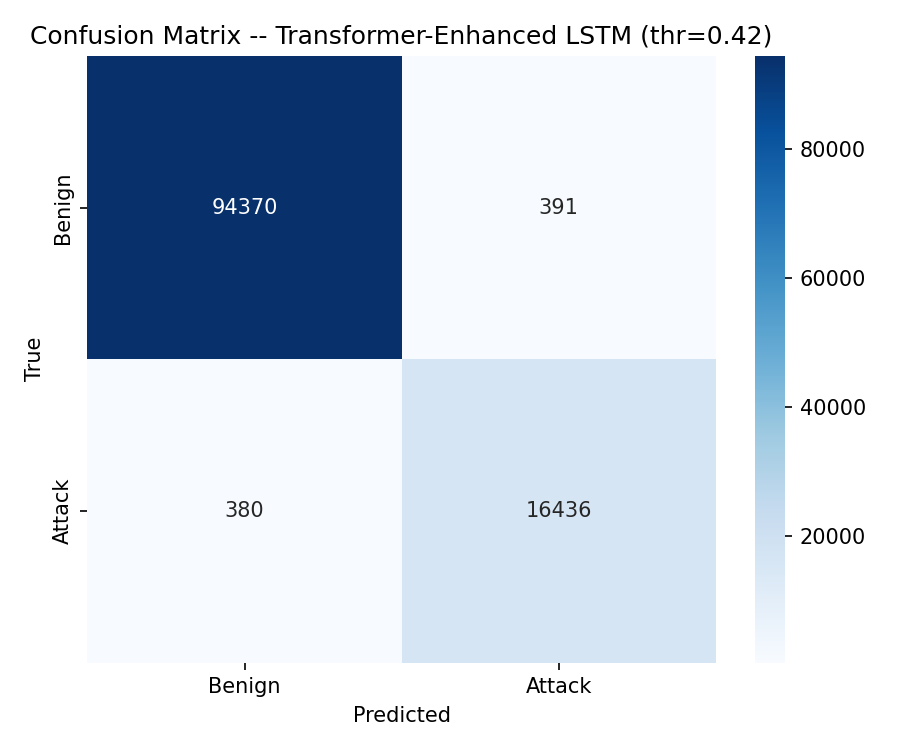

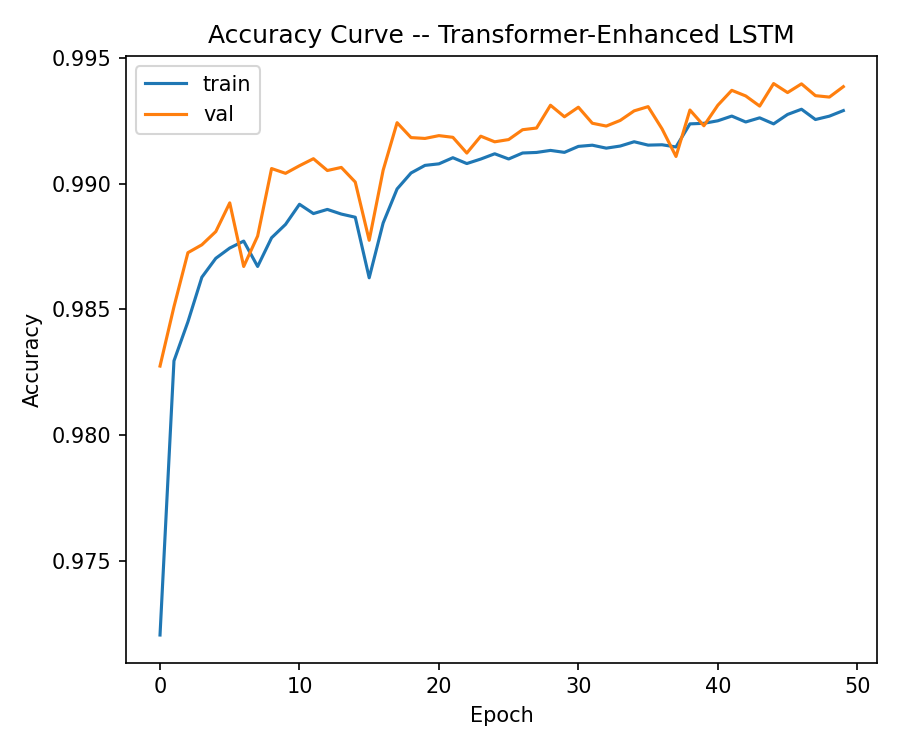

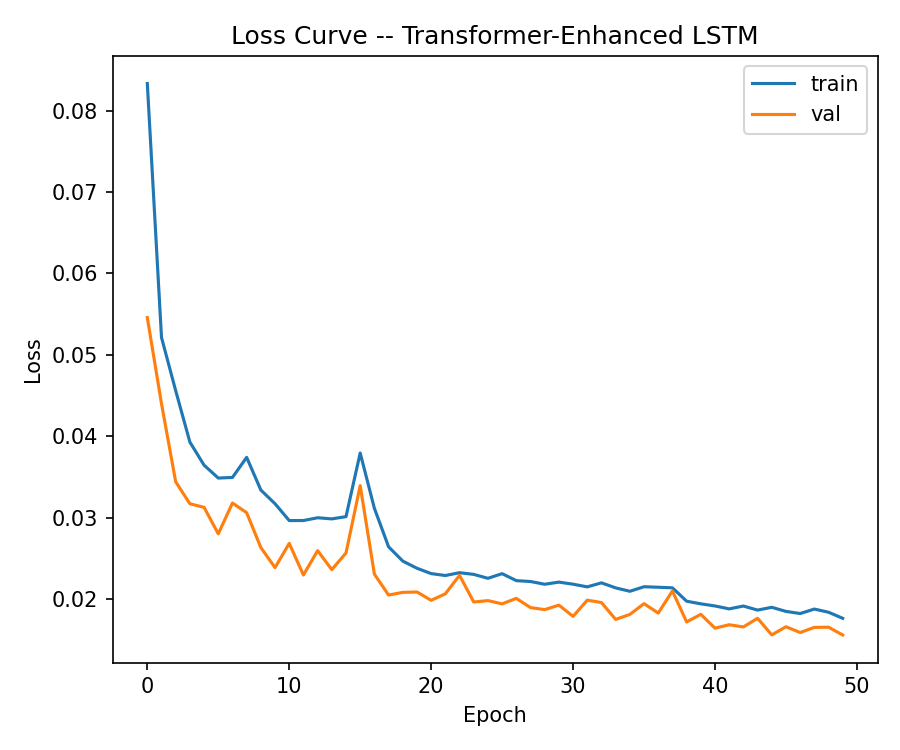

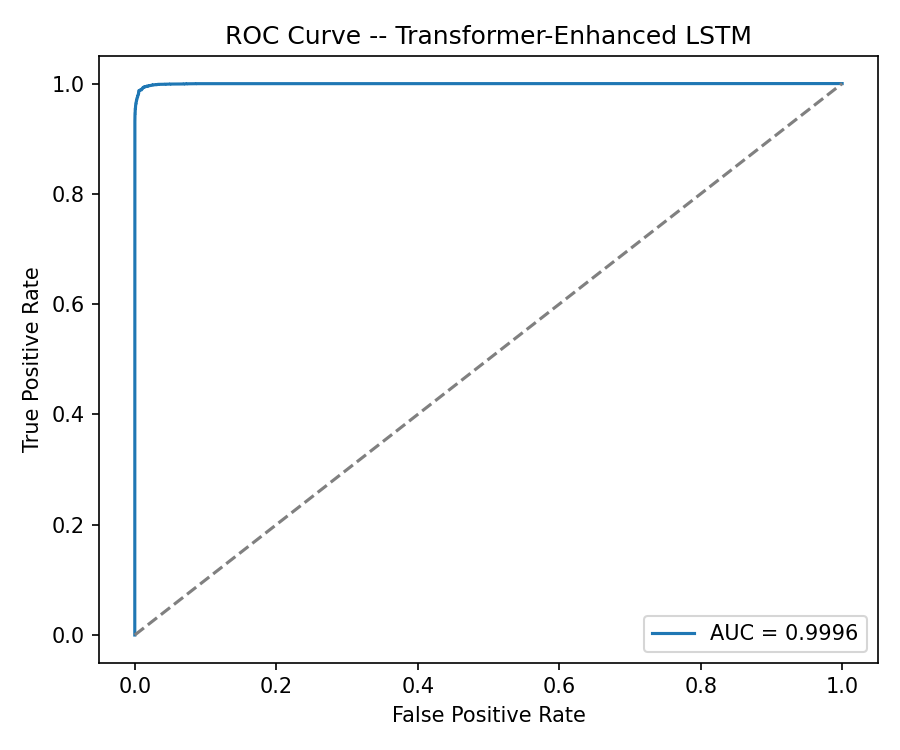

In [8]:
from IPython.display import Image, display

display(Image("results/ids_binary/confusion_matrix.png"))
display(Image("figures/ids_binary/accuracy_curve.png"))
display(Image("figures/ids_binary/loss_curve.png"))
display(Image("figures/ids_binary/roc_curve.png"))

In [9]:
print(open("results/ids_binary/metrics.txt").read())

Model                                       Accuracy        F1    Recall Precision       AUC Specificity
Transformer-Enhanced LSTM (thr=0.50)          0.9934    0.9779    0.9740    0.9818    0.9996      0.9968
Transformer-Enhanced LSTM (thr=best=0.42)     0.9931    0.9771    0.9774    0.9768    0.9996      0.9959



## Task 2: `ids_family` (coarse attack families)

BENIGN plus 7 coarse families (DoS/DDoS, Brute-Force, Web-Attack, Botnet, PortScan, Infiltration, Other). Judge by **macro-F1** and the confusion matrix, not accuracy -- Benign dominates and the rarest families (Infiltration, Other/Heartbleed) are expected to be the weak spots. Not class-comparable to the CIC-Darknet2020 `fourclass` task -- different problem domain, same model generalizing to a second dataset.

In [10]:
!python src/train.py    --task ids_family

  CIC-IDS2017/Benign-Monday-no-metadata.parquet: shape=(458831, 78)
  CIC-IDS2017/Botnet-Friday-no-metadata.parquet: shape=(176038, 78)
  CIC-IDS2017/Bruteforce-Tuesday-no-metadata.parquet: shape=(389714, 78)
  CIC-IDS2017/DDoS-Friday-no-metadata.parquet: shape=(221264, 78)
  CIC-IDS2017/DoS-Wednesday-no-metadata.parquet: shape=(584991, 78)
  CIC-IDS2017/Infiltration-Thursday-no-metadata.parquet: shape=(207630, 78)
  CIC-IDS2017/Portscan-Friday-no-metadata.parquet: shape=(119522, 78)
  CIC-IDS2017/WebAttacks-Thursday-no-metadata.parquet: shape=(155820, 78)
Loaded 8 parquet files from CIC-IDS2017, combined shape (2313810, 78)
Replaced inf/-inf with NaN in 0 cells
Dropped 0 rows containing NaN
Dropped 82274 duplicate rows
Rows: 2313810 -> 2231536
Dropped 8 constant columns: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Subsampled 2231536 -> 557884 rows (stratified, f

In [11]:
!python src/evaluate.py --task ids_family

2026-06-24 13:19:27.707088: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1782307167.708683   54775 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
3487/3487 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step
Accuracy:        0.9937
Macro F1:        0.7623
Weighted F1:     0.9932
Macro Precision: 0.9221
Macro Recall:    0.7293
Macro AUC (OvR): 0.9989


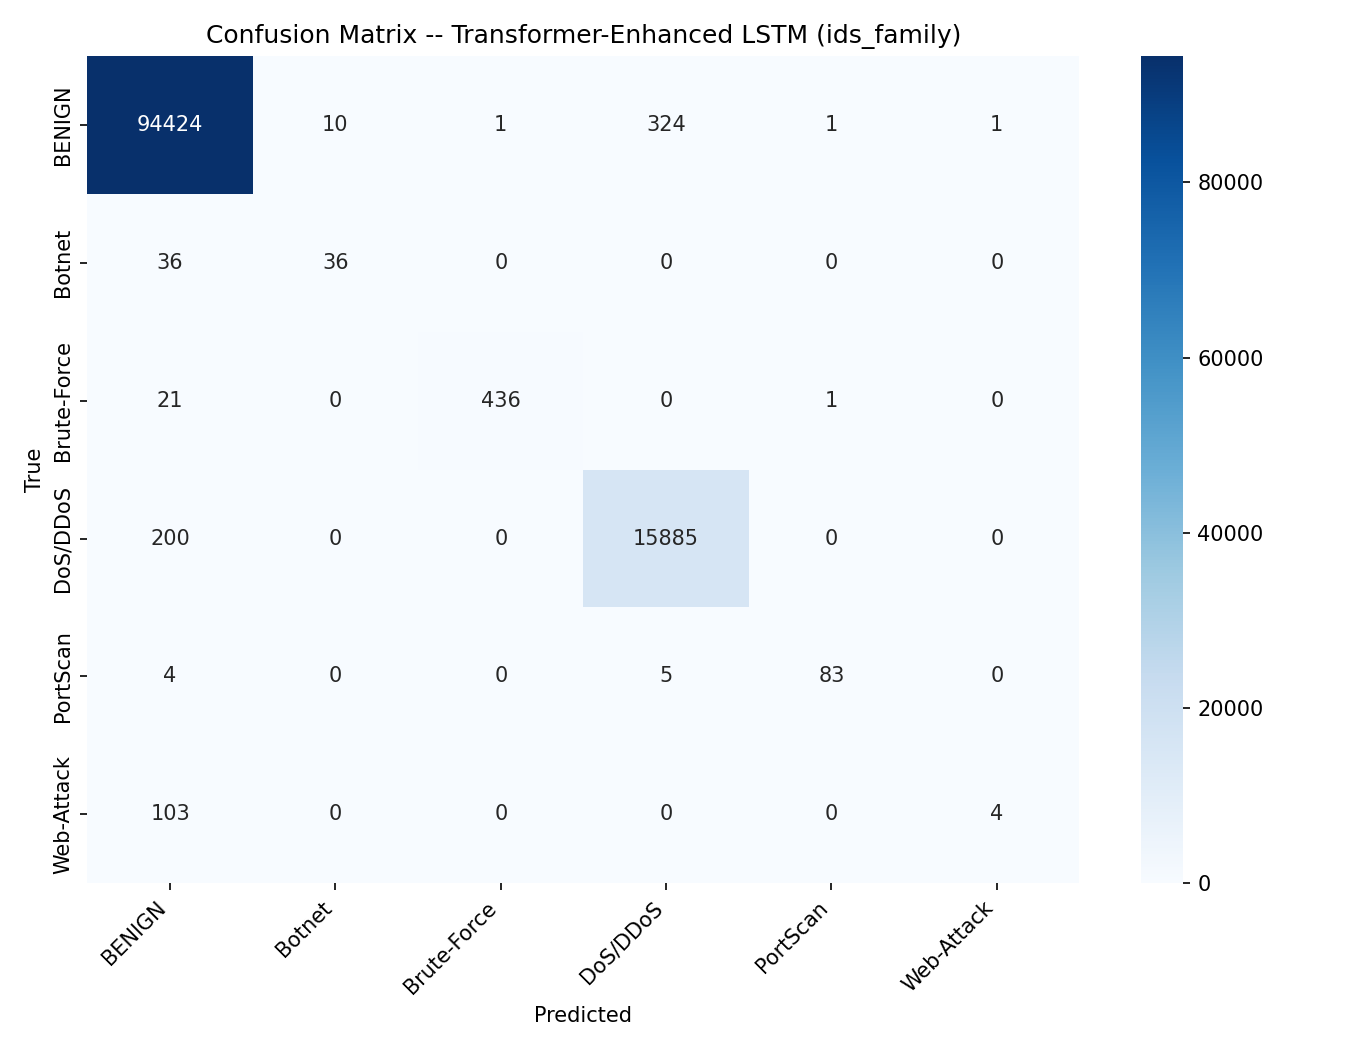

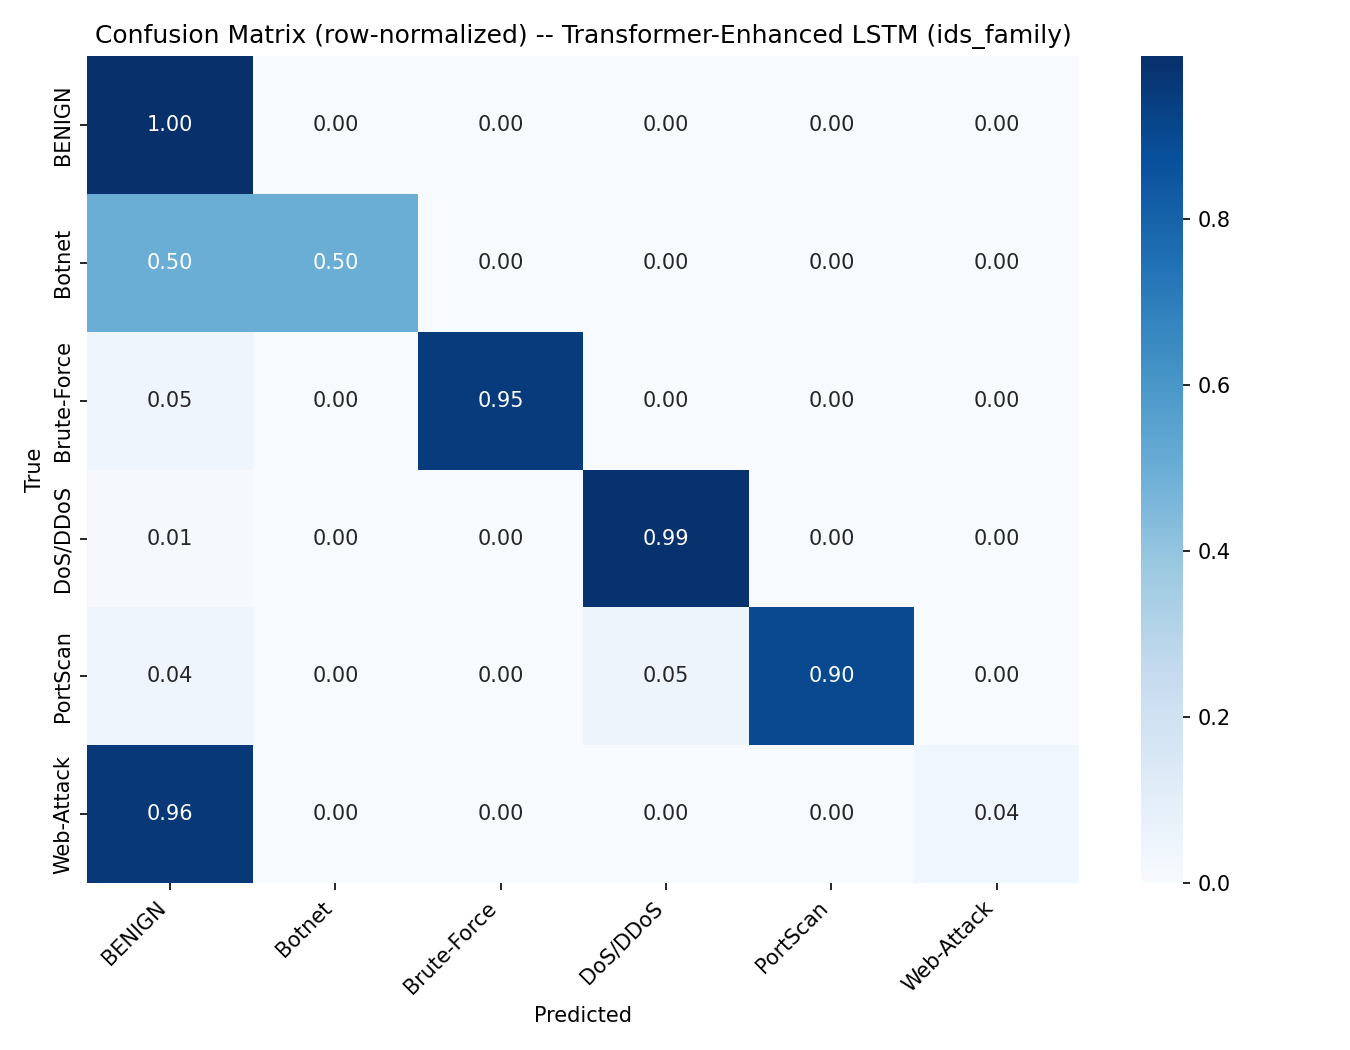

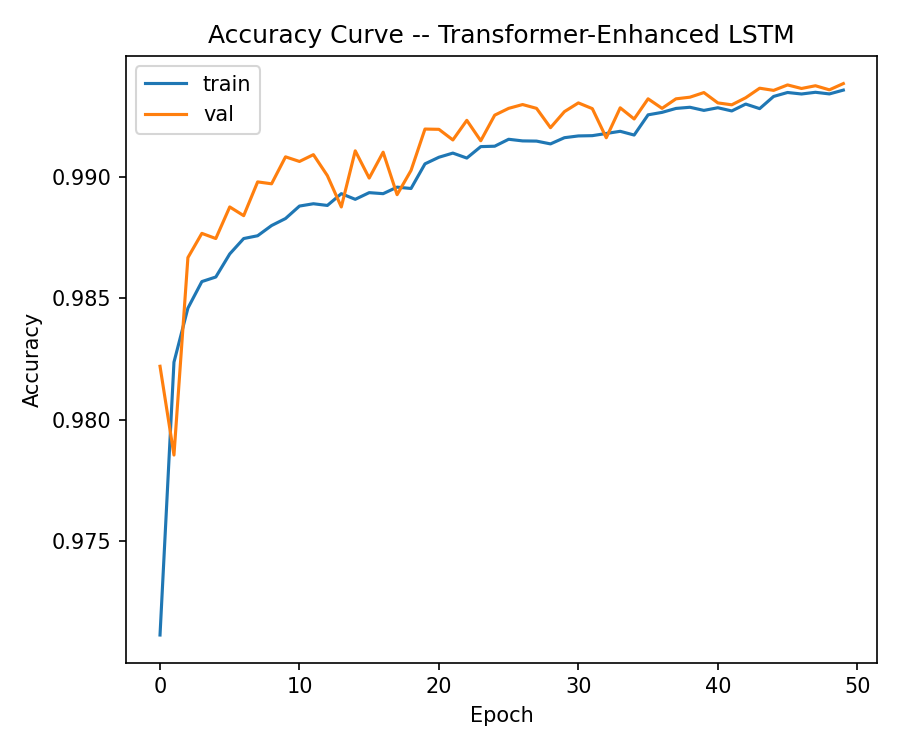

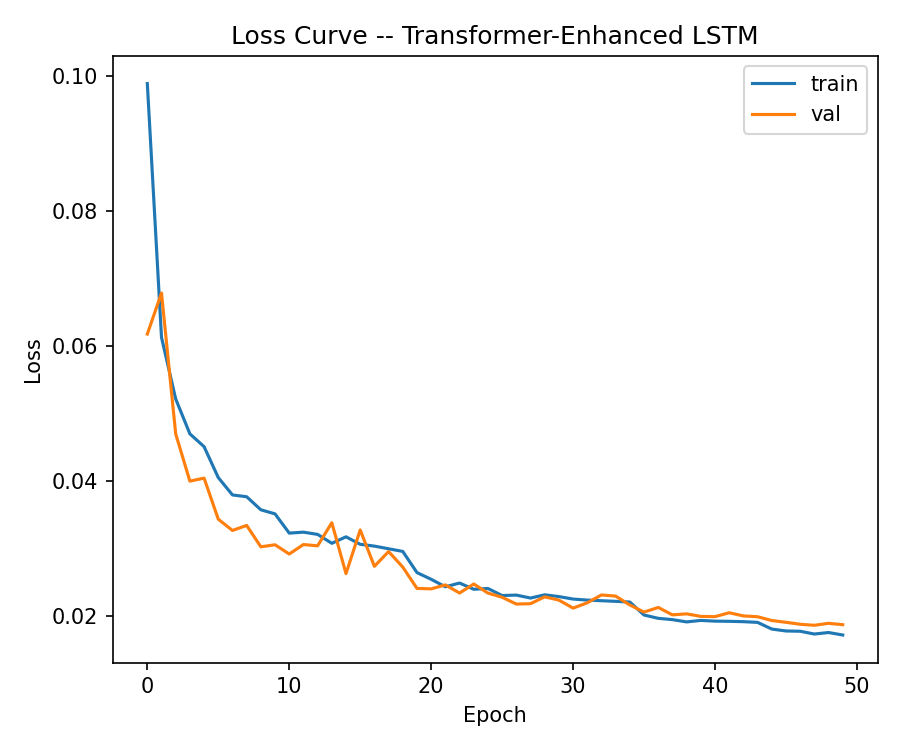

In [12]:
from IPython.display import Image, display

display(Image("results/ids_family/confusion_matrix.png"))
display(Image("results/ids_family/confusion_matrix_normalized.png"))
display(Image("figures/ids_family/accuracy_curve.png"))
display(Image("figures/ids_family/loss_curve.png"))

In [13]:
print(open("results/ids_family/metrics.txt").read())

Transformer-Enhanced LSTM -- ids_family classification (6 classes)

Accuracy:        0.9937
Macro F1:        0.7623
Weighted F1:     0.9932
Macro Precision: 0.9221
Macro Recall:    0.7293
Macro AUC (OvR): 0.9989

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     94761
      Botnet       0.78      0.50      0.61        72
 Brute-Force       1.00      0.95      0.97       458
    DoS/DDoS       0.98      0.99      0.98     16085
    PortScan       0.98      0.90      0.94        92
  Web-Attack       0.80      0.04      0.07       107

    accuracy                           0.99    111575
   macro avg       0.92      0.73      0.76    111575
weighted avg       0.99      0.99      0.99    111575



## Task 3: `ids_multi` (fine attack types)

The full fine-grained attack-type label set, with the three Web Attack variants merged into one class and the ultra-rare Infiltration/Heartbleed classes dropped (see README for the exact rare-class handling). Judge by **macro-F1** and the confusion matrix, not accuracy. Not class-comparable to the CIC-Darknet2020 `application` task -- different problem domain, same model generalizing to a second dataset.

In [14]:
!python src/train.py    --task ids_multi

  CIC-IDS2017/Benign-Monday-no-metadata.parquet: shape=(458831, 78)
  CIC-IDS2017/Botnet-Friday-no-metadata.parquet: shape=(176038, 78)
  CIC-IDS2017/Bruteforce-Tuesday-no-metadata.parquet: shape=(389714, 78)
  CIC-IDS2017/DDoS-Friday-no-metadata.parquet: shape=(221264, 78)
  CIC-IDS2017/DoS-Wednesday-no-metadata.parquet: shape=(584991, 78)
  CIC-IDS2017/Infiltration-Thursday-no-metadata.parquet: shape=(207630, 78)
  CIC-IDS2017/Portscan-Friday-no-metadata.parquet: shape=(119522, 78)
  CIC-IDS2017/WebAttacks-Thursday-no-metadata.parquet: shape=(155820, 78)
Loaded 8 parquet files from CIC-IDS2017, combined shape (2313810, 78)
Replaced inf/-inf with NaN in 0 cells
Dropped 0 rows containing NaN
Dropped 82274 duplicate rows
Rows: 2313810 -> 2231536
Dropped 8 constant columns: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Subsampled 2231536 -> 557884 rows (stratified, f

In [15]:
!python src/evaluate.py --task ids_multi

2026-06-24 14:55:08.510891: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1782312908.512412   80296 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
3487/3487 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step
Accuracy:        0.9934
Macro F1:        0.8690
Weighted F1:     0.9930
Macro Precision: 0.9607
Macro Recall:    0.8504
Macro AUC (OvR): 0.9991


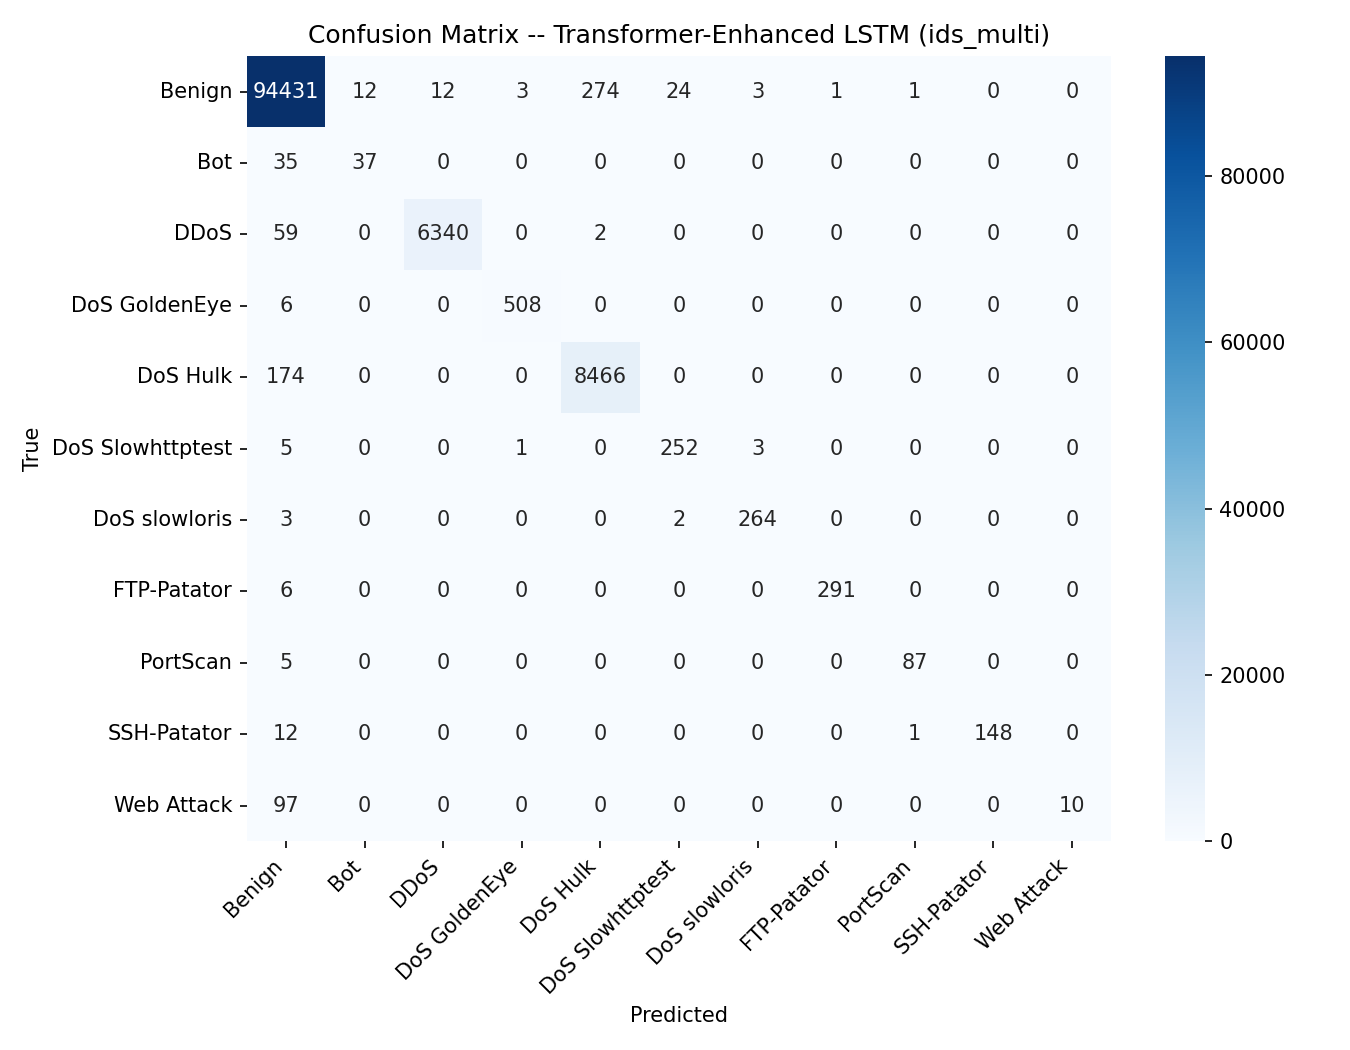

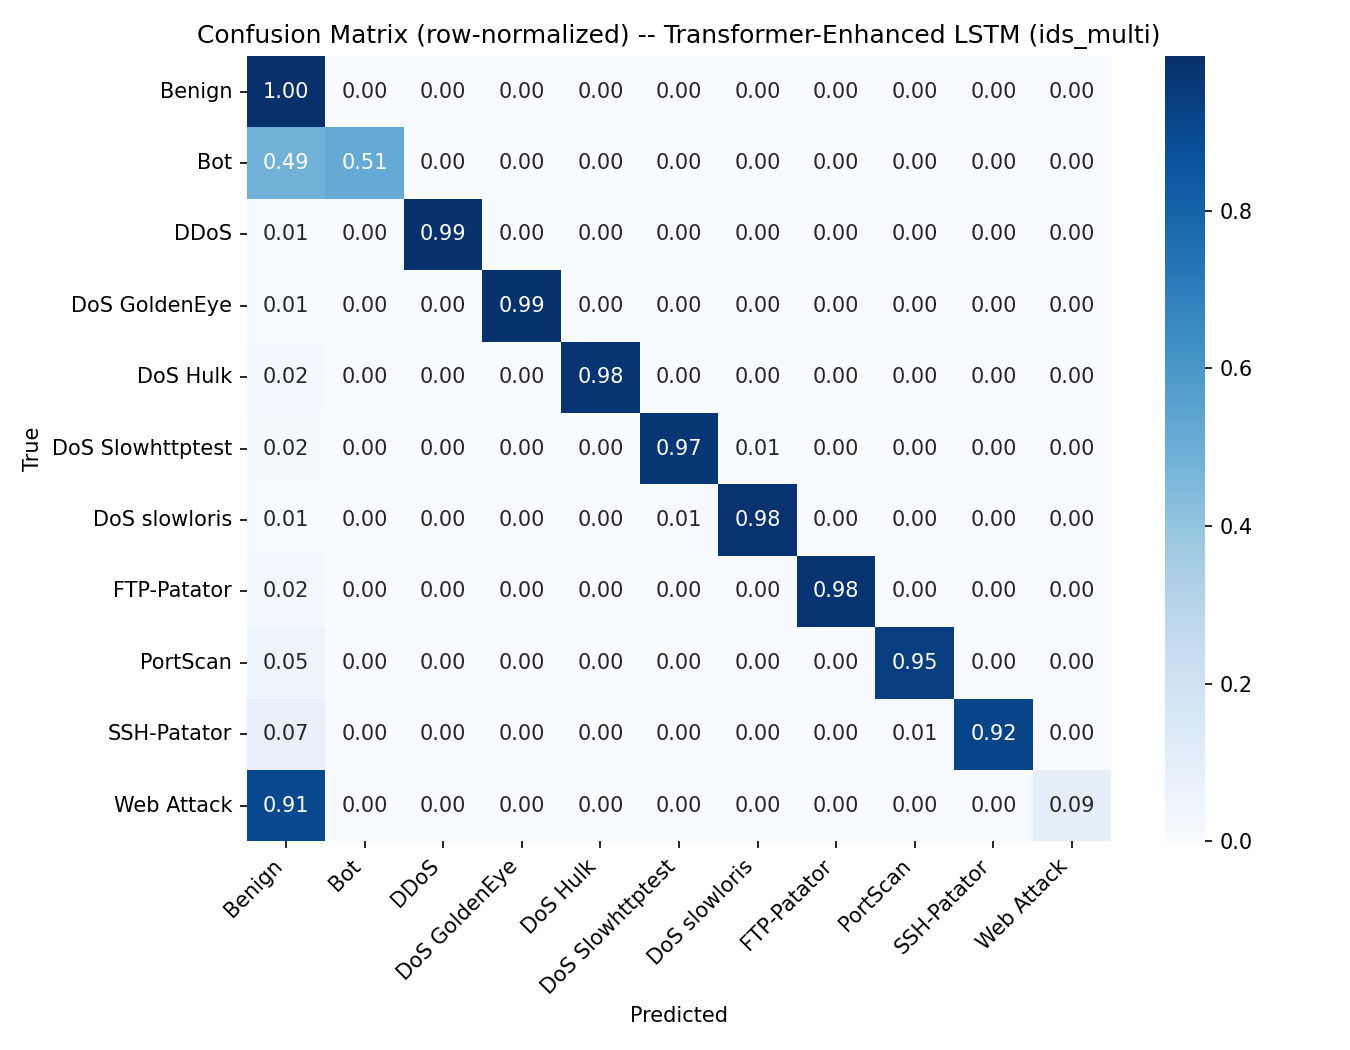

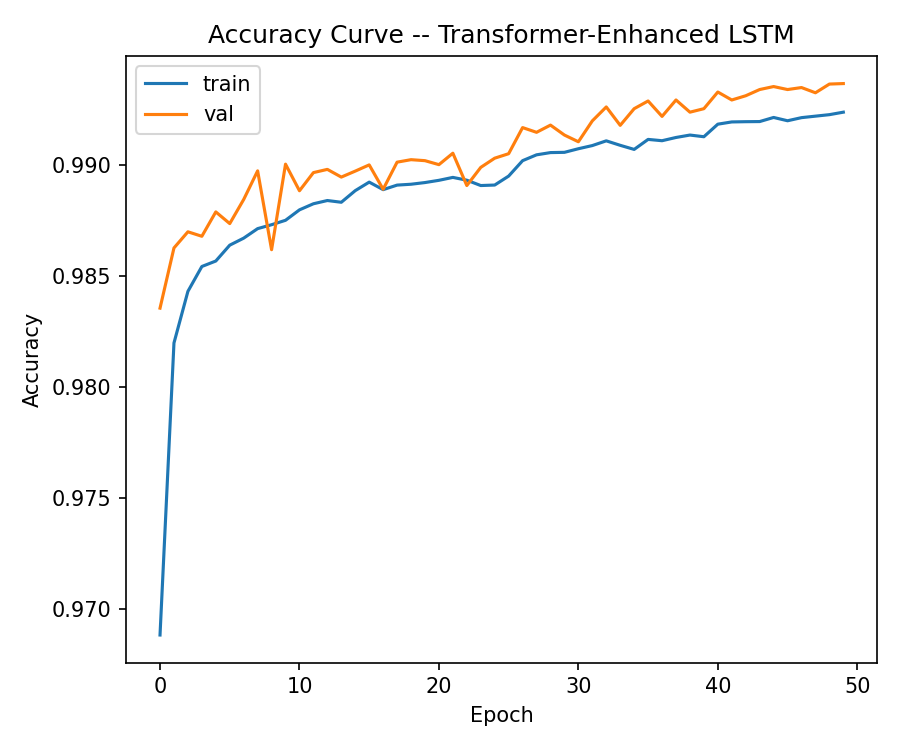

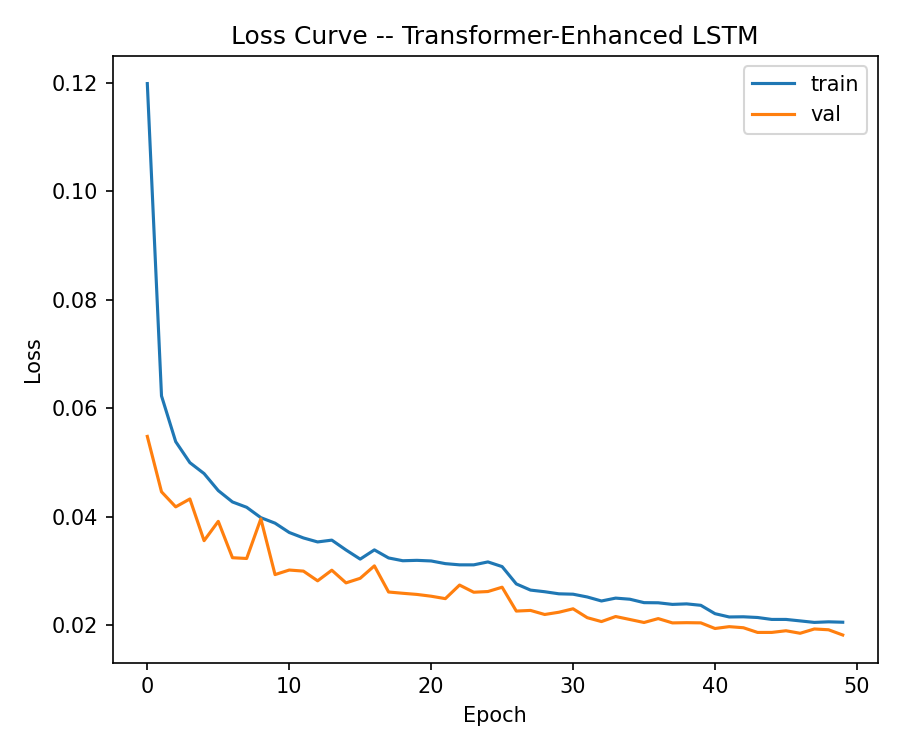

In [16]:
from IPython.display import Image, display

display(Image("results/ids_multi/confusion_matrix.png"))
display(Image("results/ids_multi/confusion_matrix_normalized.png"))
display(Image("figures/ids_multi/accuracy_curve.png"))
display(Image("figures/ids_multi/loss_curve.png"))

In [17]:
print(open("results/ids_multi/metrics.txt").read())

Transformer-Enhanced LSTM -- ids_multi classification (11 classes)

Accuracy:        0.9934
Macro F1:        0.8690
Weighted F1:     0.9930
Macro Precision: 0.9607
Macro Recall:    0.8504
Macro AUC (OvR): 0.9991

                  precision    recall  f1-score   support

          Benign       1.00      1.00      1.00     94761
             Bot       0.76      0.51      0.61        72
            DDoS       1.00      0.99      0.99      6401
   DoS GoldenEye       0.99      0.99      0.99       514
        DoS Hulk       0.97      0.98      0.97      8640
DoS Slowhttptest       0.91      0.97      0.94       261
   DoS slowloris       0.98      0.98      0.98       269
     FTP-Patator       1.00      0.98      0.99       297
        PortScan       0.98      0.95      0.96        92
     SSH-Patator       1.00      0.92      0.96       161
      Web Attack       1.00      0.09      0.17       107

        accuracy                           0.99    111575
       macro avg       0.96    

In [18]:
# Optional: zip and download results + figures for all three tasks
import shutil
from google.colab import files
shutil.make_archive("results", "zip", ".", "results")
shutil.make_archive("figures", "zip", ".", "figures")
files.download("results.zip")
files.download("figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>